In [55]:
import particles_mod.Icosphere as ico
import numpy as np
import matplotlib.pyplot as plt
import libMobility as lm
import pyvista as pv
pv.set_jupyter_backend('html')




In [56]:
num_particles = 200

radius = 5.0

density = num_particles / (4.0 * np.pi * radius**2)

icosphere = ico.IcoSphere(radius, density)


09/06/2025 11:25:36 - VLMP - INFO - [VLMP] Starting VLMP 
09/06/2025 11:25:36 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
09/06/2025 11:25:36 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
09/06/2025 11:25:36 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
09/06/2025 11:25:36 - VLMP - DEBUG - [VLMP] (system) Component parameters "{'simulationName': 'Icosphere'}" (VLMP.py:207)
09/06/2025 11:25:36 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
09/06/2025 11:25:36 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
09/06/2025 11:25:36 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
09/06/2025 11:25:36 - VLMP

In [57]:

print("Number of particles:", icosphere.nparticles)
print("Radius of the icosphere:", icosphere.radius)

Number of particles: 162
Radius of the icosphere: 5.0


In [58]:
modes, eigenvalues = icosphere.obtain_modes()


Preliminary simulation structure created
Read Hessian file /tmp/tmpbp5tkasj/hessian.txt with shape (26244, 11)


[WARNING] UAMMD-structured Python wrapper is not compatible with UAMMD-structured self restarting mechanism
[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: May 23 2025 13:23:39
[MESSAGE] Compiled in double precision mode
[MESSAGE] Computation started at Mon Jun  9 11:25:37 2025

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 3080 with id: 0
[MESSAGE] [System] Compute capability of the device: 8.6
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [ExtendedSystem] (system) Name: Icosphere
[MESSAGE] [ExtendedSystem] (system) Seed: 1749461137183527709
[MESSAGE] [GlobalDataBase] Fundamental not specified, using default fundamental, "Time"
[WARNING] [Time] No timeStep specified, using 0.0 as default.
[MESSAGE] [Basic] Loaded type A, mass: 1.000000, radius: 0.500000, charge: 0.000000
[MES

In [59]:

def plot_positions(positions, radius=1.0):
    """
    Plot the positions of particles in 3D.
    Args:
        positions: Array of particle positions.
        radius: Radius of the spheres representing particles.
    """
    plotter = pv.Plotter()
    for pos in positions:
        sphere = pv.Sphere(radius=radius, center=pos)
        plotter.add_mesh(sphere, color='blue', opacity=0.5)
    plotter.window_size = [400, 400]
    plotter.show()

plot_positions(icosphere.positions, radius=1)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

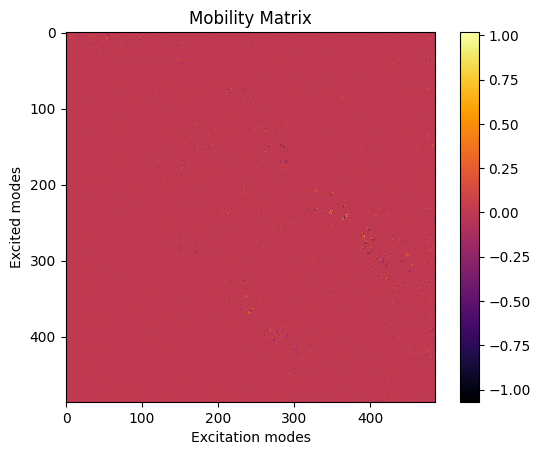

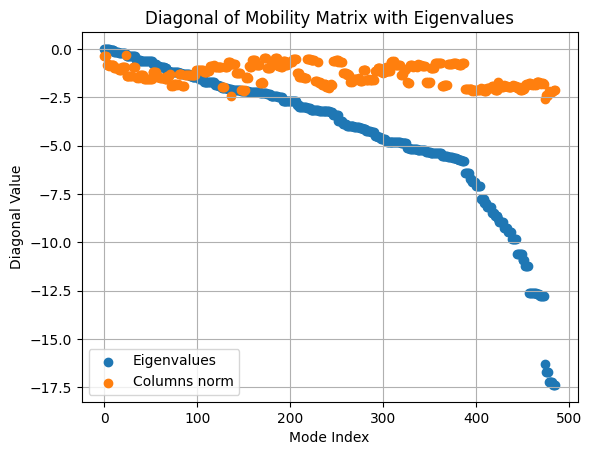

In [ ]:

precision = np.float32 if lm.SelfMobility.precision == "float" else np.float64

def create_solver(model: str = "SelfMobility"):
    """
    Create a solver based on the specified model.
    Args:
        model: The model to use for the solver. Options are "SelfMobility" or "NBody".
    Returns:
        solver: An instance of the solver for the specified model.
    """

    if model == "SelfMobility":
        solver = lm.SelfMobility("open", "open", "open")
        solver.setParameters(5)
    elif model == "NBody":
        solver = lm.NBody("open", "open", "single_wall")
        solver.setParameters(wallHeight = -radius - 1.0)
    
    solver.initialize(
        temperature=0.0,
        viscosity=1/(6 * np.pi),
        hydrodynamicRadius=1.0,
        needsTorque=False,
    )
    return solver

def create_forces_from_modes(modes, eigenvalues):
    forces = - modes * eigenvalues.T
    return forces

def construct_mobility_matrix(modes, eigenvalues, solver):
    mobility_matrix = np.zeros((icosphere.nparticles * 3, icosphere.nparticles * 3), dtype=precision)
    for mode_index in range(modes.shape[1]):
        force = -eigenvalues[mode_index] * modes[:, mode_index].reshape((icosphere.nparticles, 3))
        velocity = solver.Mdot(forces=force)[0]
        mobility_matrix[:, mode_index] = velocity.reshape((icosphere.nparticles * 3,))
    mobility_matrix = modes.T @ mobility_matrix
    return mobility_matrix
        
def plot_mobility_matrix(mobility_matrix):
    """
    Plot the mobility matrix as a heatmap.
    Args:
        mobility_matrix: The mobility matrix to plot.
    """
    plt.figure()
    # imshow in log scale to visualize the range of values
    plt.imshow(mobility_matrix, cmap='inferno')
    plt.title("Mobility Matrix")
    plt.xlabel("Excitation modes")
    plt.ylabel("Excited modes")
    plt.colorbar()
    plt.show()

def plot_diagonal(mobility_matrix):
    """
    Plot the diagonal of the mobility matrix.
    Args:
        mobility_matrix: The mobility matrix to plot.
    """
    plt.scatter(range(mobility_matrix.shape[0]), mobility_matrix.diagonal(), s=1)
    plt.title("Diagonal of Mobility Matrix")
    plt.xlabel("Mode Index")
    plt.ylabel("Diagonal Value")
    plt.grid()



positions = icosphere.positions.astype(precision)
assert positions.shape == (icosphere.nparticles, 3)

solver = create_solver("NBody") 
solver.setPositions(positions)

forces = create_forces_from_modes(modes, eigenvalues)

aux = modes.T @ forces + np.diag(eigenvalues)
assert np.all(np.isclose(aux, 0.0, atol=1e-10)), "Auxiliary check failed, not close to zero."

mobility_matrix = construct_mobility_matrix(modes, eigenvalues, solver)

diagonal_values = mobility_matrix.diagonal()

plot_mobility_matrix(mobility_matrix-np.diag(diagonal_values))

Eigv_from_modes = np.linalg.norm(mobility_matrix, axis=1)

plt.figure()
plt.scatter(range(eigenvalues.shape[0]), -eigenvalues, label='Eigenvalues')
plt.scatter(range(eigenvalues.shape[0]),-Eigv_from_modes, label='Columns norm')
plt.title("Diagonal of Mobility Matrix with Eigenvalues")
plt.xlabel("Mode Index")
plt.ylabel("Diagonal Value")
plt.legend()
plt.grid()
plt.show()